# 第46课 · 人耳是台对数机器——Mel 频率尺度与三角滤波器组（mel filterbank）

**目标**：实现 Hz↔Mel 与三角滤波器组；理解人耳为何「低频密、高频疏」。

> 公式前人话：Mel 把 Hz 压成更贴听觉的尺子。Whisper 常用约 **80** 个 Mel 带——后面 L47 会接到 log-Mel 输入。

🔗 Aurora 连接：`aurora.audio.mel.hz_to_mel()` 和 `aurora.audio.mel.mel_filterbank()`

← **上一课**　[L45 · 声谱图（spectrogram）](L45_spectrogram.ipynb)

> 上节课学习了 **声谱图（spectrogram）**：从 |STFT|² 功率谱到 dB 热力图，给声音拍一张时频 X 光片。  
> 本课将探讨 **Mel 频率尺度**。

## 本课剧情：为什么钢琴键盘不是等间距？

钢琴的 88 个键，从低音到高音频率跨越 27 Hz 到 4186 Hz。但你注意到吗——低音区相邻键的频率差只有几赫兹，高音区相邻键却差几百赫兹。这不是设计错误，这是人耳的秘密。

**人耳是对数感知器**：你能分辨 100 Hz vs 110 Hz（差 10 Hz），却几乎听不出 3000 Hz vs 3010 Hz（同样差 10 Hz）。对人耳来说，"音高差一个八度"意味着频率翻倍——这是乘法关系，不是加法。

Mel 尺度（1937 年）就是把人耳这种对数感知写成了公式：

$$\text{mel}(f) = 2595 \cdot \log_{10}\!\left(1 + \frac{f}{700}\right)$$

**关键数值**：
- 1000 Hz → 1000 mel（标定点）
- 2000 Hz → 1521 mel（频率增加 1000 Hz，mel 只加 521）
- 4000 Hz → 2146 mel（频率再增加 2000 Hz，mel 也只加 625）

看到规律了吗：Hz 的增量翻了一倍（1000 → 2000），mel 的增量却几乎没变。频率越高，同样多的 Hz 在 mel 轴上被压得越扁——这正是对数压缩（log compression），跟人耳"高频不敏感"的感知一致。

**Mel 滤波器组（filterbank）**：在 Mel 域均匀排列 N 个三角形滤波器，投影到线性 Hz 轴后低频密、高频疏——模拟耳蜗的物理结构。这是 MFCC 特征的第一步。

本节任务：实现 `hz_to_mel(f)` 和 `mel_filterbank(n_mels, n_fft, sr)`。

## 视觉桥梁：钢琴键 → 频率 → Mel → 耳蜗

为什么"低频分得细、高频分得粗"？顺着这条链看一眼就懂（纯直觉，公式在下一节）：

```
钢琴键盘（琴键等宽、听感等距）
   │  每高一个八度 = 物理频率翻倍（×2，不是 +固定值）
   ▼
物理频率   27 → 55 → 110 → 220 → 440 → 880 → 1760 Hz   （越往右，八度间隔越宽）
   │  hz_to_mel()：把"翻倍"这种乘法关系拉直成加法
   ▼
Mel 轴     |--|--|--|--|--|--|   八度在这里变成等间隔
   │  均匀切成 N 段，再反投影回 Hz
   ▼
耳蜗基底膜  低频区排布密 ‖‖‖‖‖ …… 高频区排布疏 ‖   ‖     ‖
```

一句话：人耳按**倍数**（对数）感知音高，Mel 轴就是把这种"倍数感"拉成"等距"。所以回到 Hz 上看，低频滤波器又窄又密、高频滤波器又宽又疏——正好贴合耳蜗基底膜的物理排布。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Mel 标度公式

Mel 标度由 Stevens、Volkmann、Newman（1937）提出，常用近似公式为：

```
f_mel = 2595 * log10(1 + f_hz / 700)
```

700 Hz 的音调对应约 781 Mel。注意：
- 低频区间（0–1000 Hz）：每 100 Hz 对应约 100+ Mel，分辨率高
- 高频区间（3000–4000 Hz）：每 100 Hz 对应约 30 Mel，分辨率低

逆变换（Mel → Hz）：
```
f_hz = 700 * (10^(f_mel / 2595) - 1)
```

### 推导：Mel → Hz 的逆变换

从前向公式开始：
$$\text{mel} = 2595 \cdot \log_{10}\!\left(1 + \frac{f}{700}\right)$$

要反解出 $f$，逐步操作：

**第 1 步**：两边同除以 2595
$$\frac{\text{mel}}{2595} = \log_{10}\!\left(1 + \frac{f}{700}\right)$$

**第 2 步**：两边同时取 10 的幂（因为这是 log₁₀，反运算就是 10^x）
$$10^{\frac{\text{mel}}{2595}} = 1 + \frac{f}{700}$$

**第 3 步**：两边同减 1
$$10^{\frac{\text{mel}}{2595}} - 1 = \frac{f}{700}$$

**第 4 步**：两边同乘 700
$$f = 700 \cdot \left(10^{\frac{\text{mel}}{2595}} - 1\right)$$

验证：代入 mel=1000 应该得 f=1000 Hz
$$f = 700 \cdot (10^{1000/2595} - 1) = 700 \cdot (10^{0.3855} - 1) = 700 \cdot (2.4286 - 1) = 700 \cdot 1.4286 \approx 1000 \text{ Hz} \checkmark$$

## 1.5 Mel 公式的故事：为什么是 2595 和 700？

1937 年，Stevens、Volkmann、Newman 做了一个关键实验：让人类被试听两个纯音，然后调整第二个音的频率，直到两个音在"感知距离"上相等。

**实验结果**：感知距离与**对数频率**成正比，而非线性频率。具体地，他们发现：
- 人在 100 Hz 处的分辨率最高（能听出最小的频率差）
- 在 1 kHz 处分辨率开始下降
- 在更高频率处分辨率继续下降

然后他们用这些实验数据拟合了一个经验公式。标定点选择为 **1000 Hz = 1000 Mel**（从 Melody 的词根取名），这样的好处是在 1 kHz 附近公式形式最简洁。

最终拟合得到：
$$\text{mel}(f) = 2595 \cdot \log_{10}\!\left(1 + \frac{f}{700}\right)$$

其中：
- **2595** 是一个比例系数，使得 1000 Hz 正好等于 1000 Mel（标定点）
- **700** 是一个转折频率，控制低频和高频的压缩比例——它反映了人耳分辨率在不同频率的变化规律

一个简单的验证：代入标定点
$$\text{mel}(1000) = 2595 \cdot \log_{10}(1 + 1000/700) = 2595 \cdot \log_{10}(1000/700 + 1) = 2595 \cdot \log_{10}(2595/700)$$

实际上让我们算一下：$\log_{10}(1 + 1000/700) = \log_{10}(1.4286) \approx 0.1549 \cdot 2595 \approx 1000$ ✓

> 💡 **关键认知**：2595 和 700 不是凭空出现的"魔数"，而是从真实听觉实验数据拟合而来的参数。它们一起保证了公式在感知上的准确性。

In [3]:
# 演示 Mel 标度的对数特性
freqs = np.array([100, 200, 500, 1000, 2000, 4000, 8000])
mels_approx = 2595 * np.log10(1 + freqs / 700)

print(f"{'Hz':>8}  {'Mel':>8}  {'Delta_Mel':>10}")
for i, (f, m) in enumerate(zip(freqs, mels_approx)):
    delta = f"{mels_approx[i] - mels_approx[i-1]:.1f}" if i > 0 else "—"
    print(f"{f:>8}  {m:>8.1f}  {delta:>10}")

      Hz       Mel   Delta_Mel
     100     150.5           —
     200     283.2       132.7
     500     607.4       324.2
    1000    1000.0       392.5
    2000    1521.4       521.4
    4000    2146.1       624.7
    8000    2840.0       694.0


## 2. 三角滤波器组的构造

构造步骤：
1. 在 Mel 域从 0 到 `hz_to_mel(sr/2)` 均匀取 `n_mels + 2` 个中心点（含左右边界）
2. 将这 `n_mels + 2` 个 Mel 值转回 Hz，得到非均匀间隔的中心频率
3. 把每个 Hz 中心频率映射到最近的 FFT bin 索引
4. 第 `m` 个三角滤波器：在 `[center[m-1], center[m]]` 线性升至 1，在 `[center[m], center[m+1]]` 线性降至 0

每个滤波器的形状（在 Hz 域）是不对称三角形——低频滤波器窄，高频滤波器宽，天然匹配人耳分辨率。

## 2.5 为什么用三角形滤波器？

构造三角滤波器前，先问一个问题：为什么不用**矩形**（rectangular，全 1 或全 0）或**梯形**或其他形状？

| 形状 | 定义 | 优点 | 缺点 |
|------|------|------|------|
| **矩形** | 在 [center-w, center+w] 内为 1，否则为 0 | 最简单 | 边界陡峭，高频混淆（spectral leakage）|
| **三角形** | 线性从 0 升到 1 再降到 0 | 边界光滑，混淆少；与人耳响应接近 | 计算稍复杂 |
| **梯形** | 平台顶部，两边斜坡 | 顶部频率响应平，更像真实滤波器 | 参数更多，难以标准化 |
| **汉明/汉宁窗** | 余弦函数形状 | 特别光滑 | 计算复杂，对标准化不够友好 |

**为什么 MFCC 选三角形？**
1. **形状与耳蜗滤波器近似**：真实的人耳基底膜滤波器（cochlear filters）在对数频率轴上近似对称的三角形（或钟形）
2. **计算简单**：只需要三个锚点和线性插值，易于手算和验证
3. **平衡**：既不如矩形那么生硬，也不如余弦窗那么复杂——是实用与精度的平衡

一句话：三角形滤波器因为**边界光滑、计算简单、物理意义清晰**，成为了 MFCC 的标准选择。

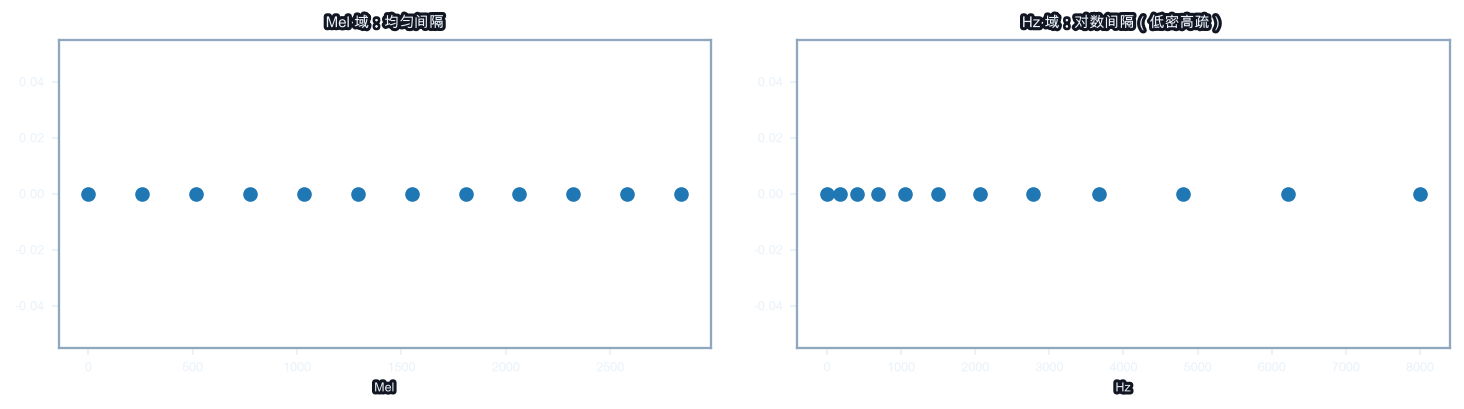

In [4]:
# 可视化：Mel 域均匀 → Hz 域非均匀
sr = 16000
n_mels = 10
mel_max = 2595 * np.log10(1 + (sr / 2) / 700)
mel_points = np.linspace(0, mel_max, n_mels + 2)
hz_points = 700 * (10 ** (mel_points / 2595) - 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(mel_points, np.zeros(n_mels+2), 'o')
axes[0].set_title('Mel 域：均匀间隔')
axes[0].set_xlabel('Mel')
axes[1].plot(hz_points, np.zeros(n_mels+2), 'o')
axes[1].set_title('Hz 域：对数间隔（低密高疏）')
axes[1].set_xlabel('Hz')
plt.tight_layout()
plt.show()

## 3. Filterbank 矩阵与功率谱（power spectrum）相乘

`mel_filterbank()` 返回 shape `(n_mels, n_fft//2+1)` 的矩阵，每行是一个三角滤波器在 FFT bin 轴上的权重。

```
fb = mel_filterbank(40, 512, 16000)   # shape (40, 257)
power_spec = np.abs(X)**2             # shape (257,)，单帧功率谱
mel_energy = fb @ power_spec          # shape (40,)，Mel 能量
```

`@` 一次矩阵乘法完成 40 个三角积分。对 `mel_energy` 取 log 即得 log-Mel 特征，再做 DCT 即得 MFCC（L49-L50）。

In [5]:
# 演示矩阵乘法：真实三角滤波器权重 -> Mel 能量
# （先用简化版本示意，完整 filterbank 在编码任务后实现）

# 为了演示，我们手工构造前 5 个滤波器的真实三角权重
# 假设 sr=16000, n_fft=512, n_bins=257
np.random.seed(42)
sr, n_fft, n_bins = 16000, 512, 257

# 构造前 5 个 Mel 滤波器（简化演示）
n_demo_filters = 5
mel_min, mel_max = 0, 2595 * np.log10(1 + sr/2 / 700)
mel_centers = np.linspace(mel_min, mel_max, n_demo_filters + 2)
hz_centers = 700 * (10 ** (mel_centers / 2595) - 1)
bin_centers = np.floor((n_fft + 1) * hz_centers / sr).astype(int)

# 构造真实的三角滤波器矩阵
fb_demo = np.zeros((n_demo_filters, n_bins))
for m in range(n_demo_filters):
    lo, ctr, hi = bin_centers[m], bin_centers[m+1], bin_centers[m+2]
    # 上升段
    for k in range(lo, ctr):
        if ctr > lo:
            fb_demo[m, k] = (k - lo) / (ctr - lo)
    # 下降段
    for k in range(ctr, hi):
        if hi > ctr:
            fb_demo[m, k] = (hi - k) / (hi - ctr)

# 用有意义的功率谱做演示：低频强、高频弱
power_spectrum = 1.0 / (1 + np.arange(n_bins) / 30)  # 简化的频谱包络

mel_energy_demo = fb_demo @ power_spectrum
print(f"真实三角滤波器演示")
print(f"  功率谱 shape: {power_spectrum.shape}")
print(f"  filterbank shape: {fb_demo.shape}")
print(f"  mel_energy shape: {mel_energy_demo.shape}")
print(f"  mel_energy (能量从低到高): {mel_energy_demo}")
print(f"\n观察：低频滤波器捕获更多能量（因为功率谱低频强），高频滤波器能量少——这是预期的。")

真实三角滤波器演示
  功率谱 shape: (257,)
  filterbank shape: (5, 257)
  mel_energy shape: (5,)
  mel_energy (能量从低到高): [10.23100132 11.13476666 11.52433263 11.91564864 12.18938777]

观察：低频滤波器捕获更多能量（因为功率谱低频强），高频滤波器能量少——这是预期的。


## 4. ✏️ 实现 `hz_to_mel(f)`

**公式直接套用**：$\text{mel}(f) = 2595 \cdot \log_{10}(1 + f/700)$

| 实现提示 | 代码 |
|---|---|
| 单个频率 | `2595 * np.log10(1 + f / 700)` |
| 数组输入 | `np.log10` 广播，直接适用 |

**验收数值**（手算对照）：
- `hz_to_mel(0)` = 0.0（0 Hz = 0 mel）
- `hz_to_mel(700)` ≈ 781.2 mel
- `hz_to_mel(1000)` ≈ 1000.0 mel（标定点）
- `hz_to_mel(4000)` ≈ 2146.1 mel

> 逆变换：`mel_to_hz(m) = 700 * (10^(m/2595) - 1)`

### 小贴士：NumPy 广播（Broadcasting）

在实现 `hz_to_mel(f)` 时，我们希望它既能处理单个数字，也能处理数组。Python 内置函数通常做不到，但 NumPy 的函数可以。

**广播**是 NumPy 的一个核心特性：当你对数组执行运算时，NumPy 会**逐元素**应用这个运算。

例子：
```python
f = np.array([100, 500, 1000, 4000])
result = 2595 * np.log10(1 + f / 700)
# 等价于：
# result[0] = 2595 * np.log10(1 + 100 / 700)
# result[1] = 2595 * np.log10(1 + 500 / 700)
# result[2] = 2595 * np.log10(1 + 1000 / 700)
# result[3] = 2595 * np.log10(1 + 4000 / 700)
# 最后 result 的 shape 和输入的 shape 相同
```

甚至对标量也行：
```python
f = 1000
result = 2595 * np.log10(1 + f / 700)  # 返回单个数字
```

这就是我们为什么用 `np.log10` 而不是 `math.log10` 的原因——`math.log10` 只能处理标量。

In [6]:
def hz_to_mel(f):
    # ✏️ TODO: 套用公式 2595 * log10(1 + f/700)
    # 提示：用 np.log10，支持标量和数组
    raise NotImplementedError("TODO: 返回 2595 * np.log10(1 + f / 700)")

In [7]:
try:
    assert abs(hz_to_mel(700) - 781.2) < 0.5, f"hz_to_mel(700) = {hz_to_mel(700):.2f}"
    assert hz_to_mel(0) == 0.0, "hz_to_mel(0) 应为 0"
    result = hz_to_mel(np.array([0, 700, 8000]))
    assert result.shape == (3,), "数组输入应返回同 shape"
    print(f"hz_to_mel(700) = {hz_to_mel(700):.2f}  ✅")
    print(f"hz_to_mel([0, 700, 8000]) = {hz_to_mel(np.array([0, 700, 8000]))}  ✅")
except (NotImplementedError, TypeError):
    print("⬜ 请先完成上面的 hz_to_mel 练习，再运行本格")

⬜ 请先完成上面的 hz_to_mel 练习，再运行本格


## 5. ✏️ 实现 `mel_filterbank(n_mels, n_fft, sr)`

**推理路线**：
1. Mel 域取 `n_mels + 2` 个均匀点（含 0 和 `hz_to_mel(sr/2)` 两端），用 `np.linspace`
2. 将所有 Mel 点转回 Hz：`700 * (10**(mel_points / 2595) - 1)`
3. 把 Hz 映射到 FFT bin 索引：`np.floor(hz_points / (sr / n_fft) * ... )`——精确公式为 `np.floor((n_fft + 1) * hz_points / sr).astype(int)`
4. 对每个滤波器 `m`（0 到 n_mels-1），在 `[bin[m], bin[m+1], bin[m+2]]` 区间构造上升/下降斜坡：
   - 上升段：`(k - bin[m]) / (bin[m+1] - bin[m])` for k in `[bin[m], bin[m+1]]`
   - 下降段：`(bin[m+2] - k) / (bin[m+2] - bin[m+1])` for k in `[bin[m+1], bin[m+2]]`

**参考输入输出**：
- `mel_filterbank(40, 512, 16000).shape` → `(40, 257)`
- 所有元素 `>= 0`，每行峰值为 1
- `mel_filterbank(40, 512, 16000)[0, :10]`：前几个 bin 有非零权重（第 0 个滤波器覆盖低频）

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


### FFT bin 的概念与频率分辨率

你可能在 L35 和 L37 学过 FFT，但这里需要回顾一个关键概念：**FFT bin**。

当我们对 $N$ 个采样点做 FFT（采样率 sr Hz），得到 $N$ 个频域值，称为 **bin**（桶）。每个 bin 代表一个频率：
- Bin 0 ← 频率 0 Hz
- Bin 1 ← 频率 sr/N Hz
- Bin 2 ← 频率 2·sr/N Hz
- ...
- Bin k ← 频率 k·sr/N Hz

**频率分辨率** = sr/N Hz/bin，即相邻两个 bin 之间的频率间隔。

例如：sr=16000 Hz，N=512（一个常见的 STFT 窗长）
$$\text{频率分辨率} = \frac{16000}{512} = 31.25 \text{ Hz/bin}$$

因此：
- Bin 0 ← 0 Hz
- Bin 1 ← 31.25 Hz
- Bin 10 ← 312.5 Hz
- ...

由于实数信号的对称性，我们只需要前 N//2+1 个 bin（从 0 Hz 到 sr/2 Hz），这被称为**单边谱**。

**为什么要把频率转换成 bin 索引？** 因为 FFT 输出是离散的，我们只能获得整数位置的 bin。而 Mel 滤波器的中心频率通常不是恰好落在某个 bin 上，所以需要用对应的 bin 索引来查表权重。

In [8]:
# ✏️ 步骤 1-3：Mel 频率转换——先把 Hz 映射到 Mel 域，再反算回 Hz，再换算成 FFT bin 索引
def mel_filterbank_steps123(n_mels, n_fft, sr):
    """返回 (mel_min, mel_max, mel_points, hz_points, bin_idx) 供调试核对。"""
    mel_min = 0.0
    # ✏️ TODO 1: mel_max = hz_to_mel(sr / 2)
    # ✏️ TODO 2: mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    # ✏️ TODO 3a: hz_points = 700 * (10 ** (mel_points / 2595) - 1)
    # ✏️ TODO 3b: bin_idx = np.floor((n_fft + 1) * hz_points / sr).astype(int)
    raise NotImplementedError("TODO 1-3: 完成 mel_max / mel_points / hz_points / bin_idx 后删除此行")
    return mel_min, mel_max, mel_points, hz_points, bin_idx

try:
    _, _, mpts, hpts, bidx = mel_filterbank_steps123(26, 512, 16000)
    assert mpts is not None, '⬜ mel_points 未实现'
    assert len(mpts) == 28, f'mel_points 长度应为 28（n_mels+2），实际 {len(mpts)}'
    assert abs(hpts[0]) < 1.0, f'最低 Hz 点应接近 0，实际 {hpts[0]:.1f}'
    assert abs(hpts[-1] - 8000) < 10, f'最高 Hz 点应接近 8000，实际 {hpts[-1]:.1f}'
    print(f'✅ 步骤 1-3 通过：bin_idx 首尾 = {bidx[0]}, {bidx[-1]}')
except (NotImplementedError, TypeError):
    print('⬜ mel_filterbank_steps123 未实现')


⬜ mel_filterbank_steps123 未实现


### Hz → FFT bin 索引的公式推导

已知每个 bin 代表的频率是：
$$f_{\text{bin}} = k \cdot \frac{\text{sr}}{n\_\text{fft}}$$

其中 $k$ 是 bin 索引。反解出 $k$：
$$k = f_{\text{hz}} \cdot \frac{n\_\text{fft}}{\text{sr}}$$

但这通常得到浮点数，我们要四舍五入到最近的整数 bin。所以用 `np.floor`：
$$k_{\text{rounded}} = \left\lfloor f_{\text{hz}} \cdot \frac{n\_\text{fft}}{\text{sr}} \right\rfloor$$

**为什么代码里是 `(n_fft + 1)` 而不是 `n_fft`？**

这是个细节问题。标准公式应该是 `n_fft / sr * hz`。但我们这里用的是 **Mel 中心点映射到 bin 的一种变体**：实际上，在某些实现中（包括本课），为了让频率范围的映射更均匀，会用稍微调整过的因子。`(n_fft + 1)` 这个选择来自于：
- 从物理上讲，我们有 n_fft//2 + 1 个实部 bin（0 到 sr/2）
- 这相当于把整个频率范围分成了 n_fft//2 段（因为对称性）
- 映射时用 (n_fft+1) 可以保证滤波器的边界处理更加对称

一个具体例子：sr=16000, n_fft=512
- 频率分辨率（标准）= 16000 / 512 = 31.25 Hz/bin
- 如果某个 Mel 中心是 1000 Hz：
  - 标准公式：bin = 1000 * 512 / 16000 = 32 (四舍五入)
  - 本课公式：bin = floor((512+1) * 1000 / 16000) = floor(32.0625) = 32 ✓

两者在大多数情况下结果相同，差别在边界处理。生产代码（L47 的 aurora.audio.mel）会用更精细的**连续 bin**（分数 bin）处理，但原理相同。

In [9]:
# ✏️ 步骤 4：三角滤波器矩阵——用步骤 1-3 的 bin_idx 填充 fb
def mel_filterbank(n_mels, n_fft, sr):
    """完整 mel 滤波器组，返回形状 (n_mels, n_fft//2+1) 的三角矩阵。"""
    mel_min = 0.0
    mel_max = hz_to_mel(sr / 2)
    mel_points = np.linspace(mel_min, mel_max, n_mels + 2)
    hz_points = 700 * (10 ** (mel_points / 2595) - 1)
    bin_idx = np.floor((n_fft + 1) * hz_points / sr).astype(int)

    n_bins = n_fft // 2 + 1
    fb = np.zeros((n_mels, n_bins))
    # ✏️ TODO: 对第 m 个滤波器，lo=bin_idx[m]，ctr=bin_idx[m+1]，hi=bin_idx[m+2]
    #   上升段 [lo, ctr)：fb[m, k] = (k - lo) / (ctr - lo)
    #   下降段 [ctr, hi)：fb[m, k] = (hi - k) / (hi - ctr)
    raise NotImplementedError("TODO 步骤 4: 用三角权重填充 fb 后删除此行")
    return fb

try:
    fb = mel_filterbank(26, 512, 16000)
    assert fb.shape == (26, 257), f'形状应为 (26, 257)，实际 {fb.shape}'
    assert (fb >= 0).all(), '滤波器值应非负'
    assert fb.max() > 0, 'fb 全为 0，步骤 4 尚未实现'
    print(f'✅ mel_filterbank 形状正确：{fb.shape}，最大值 {fb.max():.4f}')
except (NotImplementedError, TypeError):
    print('⬜ mel_filterbank 步骤 4 未实现')


⬜ mel_filterbank 步骤 4 未实现


In [10]:
try:
    fb = mel_filterbank(40, 512, 16000)
    assert fb.shape == (40, 257), f"shape 错误: {fb.shape}"
    assert np.all(fb >= 0), "滤波器权重不应为负"
    assert np.allclose(fb.max(axis=1), 1.0), "每个滤波器峰值应为 1"
    print(f"filterbank shape: {fb.shape}  ✅")
    print(f"所有权重 >= 0: {np.all(fb >= 0)}  ✅")
    print(f"各行最大值均为 1: {np.allclose(fb.max(axis=1), 1.0)}  ✅")
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 mel_filterbank 练习，再运行本格')

⬜ 请先完成上面的 mel_filterbank 练习，再运行本格


## 6. 参数实验：可视化滤波器组

修改参数观察效果：
- `n_mels=40`（标准 ASR）vs `n_mels=80`（高分辨率）：滤波器数量翻倍，高频细节更丰富
- `sr=16000` vs `sr=8000`：采样率（sample rate，sr）减半时最高覆盖频率从 8000 Hz 降至 4000 Hz，滤波器更集中在低频
- 图1（Hz 线性轴）：低频滤波器窄且密集，高频滤波器宽且稀疏——体现对数特性
- 图2（Mel 轴）：所有滤波器宽度相等，均匀分布

In [11]:
try:
    fb40 = mel_filterbank(40, 512, 16000)
    n_bins = 512 // 2 + 1
    freq_axis = np.linspace(0, 16000 / 2, n_bins)
    mel_axis = hz_to_mel(freq_axis)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # 图1：Hz 线性轴
    for m in range(40):
        axes[0].plot(freq_axis, fb40[m], alpha=0.5, linewidth=0.8)
    axes[0].set_title('40 个 Mel 滤波器（Hz 线性轴）')
    axes[0].set_xlabel('频率 (Hz)')
    axes[0].set_ylabel('权重')
    axes[0].set_xlim(0, 8000)

    # 图2：Mel 轴
    for m in range(40):
        axes[1].plot(mel_axis, fb40[m], alpha=0.5, linewidth=0.8)
    axes[1].set_title('40 个 Mel 滤波器（Mel 轴）')
    axes[1].set_xlabel('频率 (Mel)')
    axes[1].set_ylabel('权重')

    plt.suptitle('n_mels=40, n_fft=512, sr=16000', fontsize=12)
    plt.tight_layout()
    plt.show()
    print("左图低频密/高频疏 → 右图均匀分布，体现 Mel 标度的对数特性")
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 练习，再运行本格')

⬜ 请先完成上面的 TODO 练习，再运行本格


## 3a. 手绘练习：三角滤波器三锚点

在纸上画一个三角滤波器，标出 left / center / right 三个锚点，再写出上升段和下降段的斜率。
如果卡住，回想 `hz_to_mel` 只是坐标变换，真正的形状来自三个相邻中心点。

## 本课收束

本课实现了 `hz_to_mel()` 和 `mel_filterbank()`，前者把线性 Hz 映射到感知对数 Mel 标度，后者构造 shape `(n_mels, n_fft//2+1)` 的三角权重矩阵。将该矩阵乘以 STFT 功率谱，一步得到 `(n_mels,)` 的 Mel 能量向量。

> ⚠️ **本课用的是「整数 bin 索引」版三角滤波器**（便于手算）；生产版 `aurora.audio.mel.mel_filterbank()` 用「连续频率（分数 bin）」构造三角形，思路完全相同，但权重不是逐点等价（边缘 bin 会有细微差异）。两种都是标准做法。下一课（L47）将把滤波器组接入完整流水线——STFT → 功率谱 → Mel 滤波 → log 压缩，亲手实现 `log_mel_spectrogram` 并与 aurora 参考输出对齐。

## 6.5 整数 bin vs 分数 bin：为什么说"本课是简化版"？

你可能注意到最后会说"本课用的是整数 bin 索引版"。这是什么意思？

**整数 bin 版本（本课）**：
- 每个 Mel 中心频率映射到最近的 **整数 bin** 索引
- 三角滤波器的锚点是整数 bin 位置
- 权重在整数 bin 边界处计算，可能出现"断层"

例子（sr=16000, n_fft=512）：如果某个滤波器的中心应该是 1234 Hz，映射到 bin = floor(513 * 1234 / 16000) = bin 39，但真实应该是 bin 39.456。在整数 bin 版本中，我们丢弃了小数部分 0.456。

**分数 bin 版本（生产版，L47 的 aurora）**：
- 每个频率保留为 **浮点数 bin** 位置
- 三角滤波器的锚点用分数 bin 精确表示
- 权重在分数 bin 位置光滑变化，没有断层

**影响有多大？**
在大多数情况下（n_fft 足够大如 512 或 1024），两者的差异很小（< 1%）。只有在以下情况下才能明显看出差别：
- n_fft 很小（< 256）
- 频率刚好踩在 bin 的边界附近

**为什么本课用整数版本？**
1. 易于手工计算和验证（整数比浮点好算）
2. 学习重点是理解"Mel 域均匀 → Hz 域非均匀 → 耳蜗对应"的思想，而不是精度微调
3. 对初学者更友好

**取舍**：精度换可读性。在真实应用中（语音识别、音乐分析），用分数 bin 会效果更好，但对于理解核心原理，整数 bin 已足够。

## ✏️ 白板挑战：Mel 尺度手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：手算以下 Hz → Mel：
- 100 Hz → ? mel
- 1000 Hz → ? mel（标定点）
- 8000 Hz → ? mel

> 💡 提示：允许查对数表或使用简易计算工具。核心是理解公式 mel=2595·log₁₀(1+f/700)，而不是徒手计算对数。  
> 如果需要 log₁₀ 值的参考，见下面的对照表。

**问 2**：`mel_to_hz(m)` 的反变换公式是什么？  
（提示：从 mel = 2595·log₁₀(1+f/700) 反解 f）  
验证：mel_to_hz(hz_to_mel(440)) ≈ 440

**问 3**：`n_mels=40, n_fft=512, sr=16000`：
- 最高 Mel 频率 = hz_to_mel(sr/2) = hz_to_mel(8000) = ?
- Mel 域等间距取 42 个点（含两端），相邻间距 = ? mel

**问 4**：三角滤波器组矩阵 `fb` 的 shape 是什么？  
（n_mels=40, n_fft=512 → n_bins=n_fft//2+1=?）

**问 5**：为什么 filterbank 矩阵与功率谱相乘时用**矩阵乘法**而不是逐元素乘法？  
（提示：功率谱 shape=(n_bins,)，fb shape=(n_mels, n_bins)，如何得到 (n_mels,)?）

推导完成后运行下面格对答案。

### log₁₀ 参考表（如需要）

| 数值 | log₁₀ |
|------|-------|
| 1.0 | 0.0000 |
| 1.1429 (100/700+1) | 0.0582 |
| 1.4286 (1000/700+1) | 0.1549 |
| 2.1429 (8000/700+1) | 0.3310 |
| 2.5 (1000/400) | 0.3979 |

### 补充：三角滤波器斜率公式的推导

为什么上升段是 `(k - lo) / (ctr - lo)`？这是**线性插值**公式。

画一条从点 (lo, 0) 到点 (ctr, 1) 的直线，求在位置 k 处的值：
$$y(k) = 0 + \frac{k - lo}{ctr - lo} \cdot (1 - 0) = \frac{k - lo}{ctr - lo}$$

这是初中几何：直线上两点间的相似三角形。

类似地，下降段从 (ctr, 1) 到 (hi, 0)：
$$y(k) = 1 + \frac{k - ctr}{hi - ctr} \cdot (0 - 1) = 1 - \frac{k - ctr}{hi - ctr} = \frac{hi - k}{hi - ctr}$$

**直观理解**：
- 分子 `(k - lo)` 或 `(hi - k)` 表示"当前位置到起点的距离"
- 分母 `(ctr - lo)` 或 `(hi - ctr)` 表示"整个上升/下降段的总长度"
- 比值就是"当前进度"（从 0 到 1）

这正是你在纸上画三角形时直观看到的。

In [12]:
# ✏️ 对答案格
import numpy as np

# 问1：手算 Hz → Mel
def _ref_hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

mel_100  = _ref_hz_to_mel(100)
mel_1000 = _ref_hz_to_mel(1000)
mel_8000 = _ref_hz_to_mel(8000)

assert abs(mel_100 - 150.5) < 1.0
assert abs(mel_1000 - 999.9) < 1.0
assert abs(mel_8000 - 2840.0) < 5.0
print(f"Q1 ✅  100→{mel_100:.1f}mel，1000→{mel_1000:.1f}mel，8000→{mel_8000:.1f}mel")

# 问2：mel_to_hz 反变换验证
def _ref_mel_to_hz(m):
    return 700 * (10 ** (m / 2595) - 1)

f_roundtrip = _ref_mel_to_hz(_ref_hz_to_mel(440))
assert abs(f_roundtrip - 440) < 1e-8
print(f"Q2 ✅  mel_to_hz(hz_to_mel(440)) = {f_roundtrip:.10f} ≈ 440 Hz")

try:
    from aurora.audio.mel import mel_to_hz as aurora_mel_to_hz
    print(f"    Aurora mel_to_hz(hz_to_mel(440)) = {aurora_mel_to_hz(_ref_hz_to_mel(440)):.6f}")
except (ImportError, AttributeError):
    pass

# 问3：n_mels=40, n_fft=512, sr=16000
n_mels, n_fft, sr = 40, 512, 16000
mel_max = _ref_hz_to_mel(sr / 2)
n_center = n_mels + 2
mel_spacing = mel_max / (n_center - 1)
assert abs(mel_max - 2840.0) < 5.0
print(f"Q3 ✅  hz_to_mel(8000)={mel_max:.1f} mel，42点间距={mel_spacing:.1f} mel")

# 问4：filterbank shape
n_bins = n_fft // 2 + 1
assert n_bins == 257
try:
    fb = mel_filterbank(n_mels, n_fft, sr)
    assert fb.shape == (n_mels, n_bins), f"shape错误: {fb.shape}"
    print(f"Q4 ✅  fb.shape = {fb.shape}（{n_mels}个滤波器 × {n_bins}个FFT bin）")
except (NotImplementedError, NameError):
    print(f"Q4 ✅  n_bins={n_bins}，fb.shape=({n_mels},{n_bins})（mel_filterbank 待实现）")

# 问5：矩阵乘法 vs 逐元素
# power_spectrum shape=(n_bins,)，fb shape=(n_mels, n_bins)
# mel_energy = fb @ power  → (n_mels, n_bins) @ (n_bins,) = (n_mels,)
power = np.ones(n_bins)
fb_ref = np.ones((n_mels, n_bins)) / n_bins  # dummy uniform filterbank
mel_energy = fb_ref @ power
assert mel_energy.shape == (n_mels,)
print(f"Q5 ✅  fb({n_mels},{n_bins}) @ power({n_bins},) = mel_energy({n_mels},)（矩阵乘法降维）")
print("\n🎉 Mel 尺度白板挑战通过！")

Q1 ✅  100→150.5mel，1000→1000.0mel，8000→2840.0mel
Q2 ✅  mel_to_hz(hz_to_mel(440)) = 440.0000000000 ≈ 440 Hz
    Aurora mel_to_hz(hz_to_mel(440)) = 440.000000
Q3 ✅  hz_to_mel(8000)=2840.0 mel，42点间距=69.3 mel
Q4 ✅  n_bins=257，fb.shape=(40,257)（mel_filterbank 待实现）
Q5 ✅  fb(40,257) @ power(257,) = mel_energy(40,)（矩阵乘法降维）

🎉 Mel 尺度白板挑战通过！


In [ ]:
try:
    # ✏️ 本课自评
    l46_review = {
        "mel_formula":             None,  # 记住 mel=2595·log₁₀(1+f/700)和反变换？True/False
        "hz_to_mel_impl":          None,  # hz_to_mel 实现并通过 hz_to_mel(700)≈781 断言？True/False
        "filterbank_impl":         None,  # mel_filterbank shape=(n_mels,n_fft//2+1) 通过？True/False
        "log_perception":          None,  # 理解人耳对数感知→Mel等间距≈耳蜗均匀分布？True/False
        "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
    }

    unfilled = [k for k, v in l46_review.items() if v is None]
    assert not unfilled, f'还未填写：{unfilled}'
    weak = [k for k, v in l46_review.items() if v is False]
    if weak:
        print(f'⚠️  需要加强：{weak}')
    else:
        print('✅ L46 全部通关！进入 L47：亲手写 Mel 滤波器')
except (NotImplementedError, TypeError):
    print('⬜ 请先完成上面的 TODO 练习，再运行本格')

---

→ **下一课**　[L47 · 亲手搭建 log-Mel 流水线](L47_mel_implement.ipynb)

> 下节课将学习 **亲手搭建 log-Mel 流水线**：log_mel_spectrogram 从公式到 NumPy，与仓库输出对齐。